<a href="https://colab.research.google.com/github/EberHernandezBenitez/Simulacion-II/blob/main/MCMC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmo metropolis-Hastings
Para implementar el método MCMC necesitamos un algoritmo para generar cadenas de Markov que tengan como distribuci on límite a $f(x)$ y también un criterio para determinar que las cadenas de Markov han convergido y que nos guíe en la elección del valor $m$ en la quema de los primeros valores de la cadena.

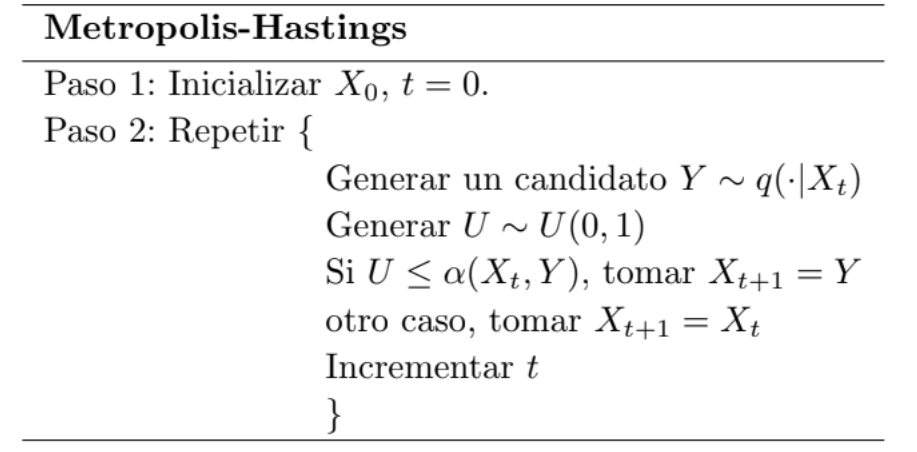

Con $$\alpha=min(1,\frac{\pi (Y)q(X|Y)}{\pi(X)q(Y|X)})$$ \
Para entender la función de este algoritmo vamos a resolver un ejercicio dado en clase aplicando este método.

Ejemplo. Simular el vector X=(x_1,x_2) que sigue: \
Sea $f(x)=C exp(-(x_1^2x_2^2+x_1^2+x_2^2-8x_1-8x_2)/2)$, con C=1/2021.6335877


Vamos a hacer el seudocódigo que resuelva y grafique la función:

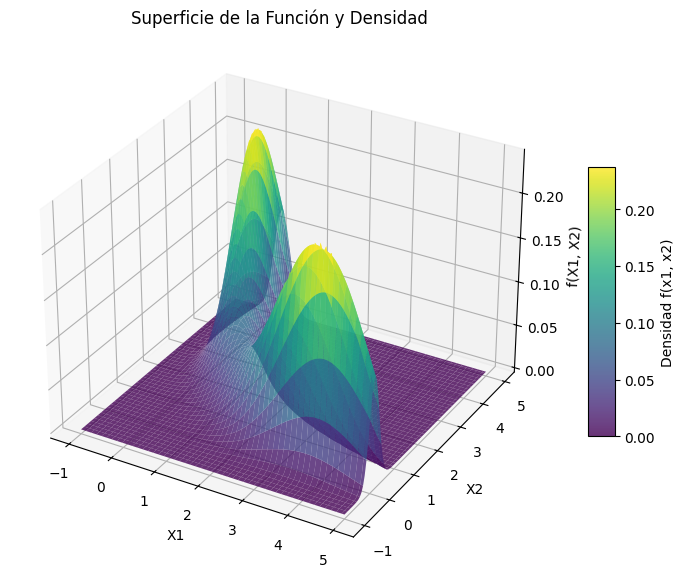

In [1]:
import random as r
import matplotlib.pyplot as plt
import numpy as np

def funcion(x1, x2):
    exponente = -( (x1**2)*(x2**2) + x1**2 + x2**2 - 8*x1 - 8*x2 ) / 2
    return (1 / 20216.335877) * np.exp(exponente)

def caminata(x1, x2, N):
    # nicializar Xt y creando los arreglos para guardar la muestra
    xt = (x1, x2)
    muestras_x1 = []
    muestras_x2 = []

    for t in range(N):
        #Generar Z ~ N(0,1) independientemente
        z1 = np.random.normal(0,1)
        z2 = np.random.normal(0,1)
        Z = (z1, z2)

        # Propuesta Y
        Y = (xt[0] + Z[0], xt[1] + Z[1])

        # Calculando la probabilidad de aceptación alpha
        f_xt = funcion(xt[0], xt[1])
        f_Y = funcion(Y[0], Y[1])

        # cuidar q no se divida entre 0
        if f_xt == 0:
            alp = 1.0 if f_Y > 0 else 0.0
        else:
            alp = min(1.0, f_Y / f_xt)

        # 3. Generar U ~ U[0,1]
        u = r.uniform(0, 1)

        # Criterio de aceptación
        if u < alp:
            xt = Y  # Hacer Xt+1 = Y
        # Si no se cumple, xt se mantiene igual (Xt+1 = Xt)

        # Guardar las muestras aceptadas o repetidas
        muestras_x1.append(xt[0])
        muestras_x2.append(xt[1])

    return np.array(muestras_x1), np.array(muestras_x2)

# Parámetros iniciales
N_muestras = 10000
x1_inicial = 0.0
x2_inicial = 0.0

m_x1, m_x2 = caminata(x1_inicial, x2_inicial, N_muestras)

#Gradicando en 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
x1_rango = np.linspace(-1, 5, 100)
x2_rango = np.linspace(-1, 5, 100)
X1, X2 = np.meshgrid(x1_rango, x2_rango)
Z_func = funcion(X1, X2)
superficie = ax.plot_surface(X1, X2, Z_func, cmap='viridis', alpha=0.8, edgecolor='none')
ax.set_title('Superficie de la Función y Densidad')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('f(X1, X2)')
fig.colorbar(superficie, ax=ax, shrink=0.5, aspect=10, label='Densidad f(x1, x2)')

plt.show()